In [31]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", None)

In [32]:
plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["font.size"] = 11

In [33]:
df = pd.read_csv("data/EDA_dataset.csv")

print(f"Total Reviews : {len(df):,}")

df.head()

Total Reviews : 194,009


,reviewId,content,score,time,year
0,e17751da-bf2e-4a8f-a5a8-334206bb93ca,"ribet banget ni apk sumpah dikir' verif dikit' verif udhmah nyedot pulsa mulu, tolong benerin lah, jangan ribet gini mau pake aja ribet cuh",1,2025-12-31 23:57:59,2025
1,3481f1d1-a22f-445f-ae2f-ed8c2c9dca53,kenapa QRis ga bisa di pakai ya?? daritadi loading mulu. transfer uang juga gabisa,2,2025-12-31 23:22:32,2025
2,af69ec6d-cc97-404e-b86a-e5f5b5f1f711,"aplikasi nya sampah, kenapa tiba-tiba keluar terus registrasi ulang lagi, harus pake SMS pulsa pula, sangat tidak membantu ,delete",1,2025-12-31 23:06:58,2025
3,32d28ac6-c538-4749-969f-8af060915d96,bagus,3,2025-12-31 21:47:45,2025
4,f99259b7-0d45-4422-b667-6c4fd521638b,tidak ada solusi ketika ada kendala di persulit di lempar kesana kesini sangat mengecewakan harusnya respon dan solusi yang di berikan,1,2025-12-31 21:18:21,2025


dataset overview

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 194009 entries, 0 to 194008
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   reviewId  194009 non-null  object
 1   content   194009 non-null  object
 2   score     194009 non-null  int64 
 3   time      194009 non-null  object
 4   year      194009 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 7.4+ MB


Rating Distribution

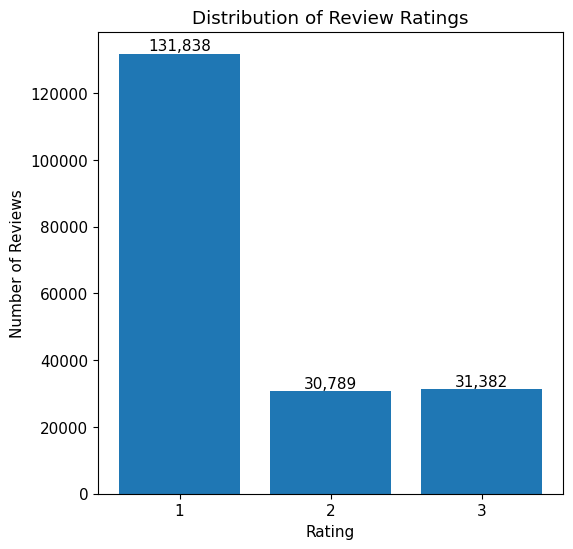

In [35]:
rating_count = (
    df["score"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(6,6))

plt.bar(
    rating_count.index.astype(str),
    rating_count.values
)

plt.title("Distribution of Review Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

for i, v in enumerate(rating_count.values):
    plt.text(i, v, f"{v:,}", ha="center", va="bottom")

plt.show()

most of the reviews dominated with 1 stars which is what we're hoping for for this research

Review Length (Characters)

In [36]:
df["character_length"] = (
    df["content"]
    .astype(str)
    .str.len()
)

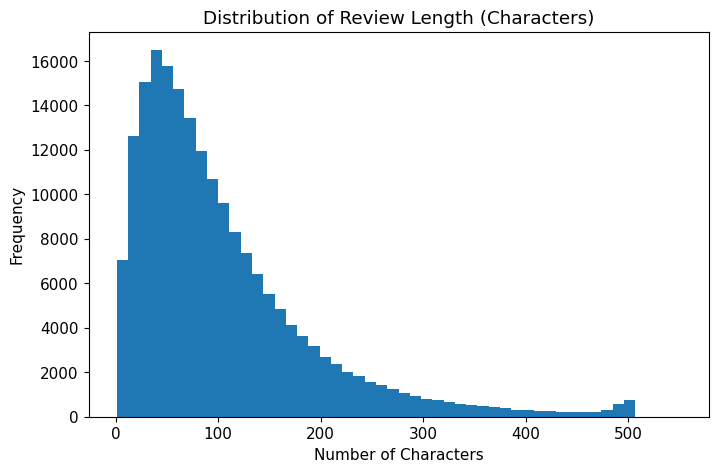

In [37]:
plt.figure(figsize=(8,5))

plt.hist(
    df["character_length"],
    bins=50
)

plt.title("Distribution of Review Length (Characters)")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.show()


Review Length (Words)

In [38]:
df["word_length"] = (
    df["content"]
    .astype(str)
    .str.split()
    .str.len()
)

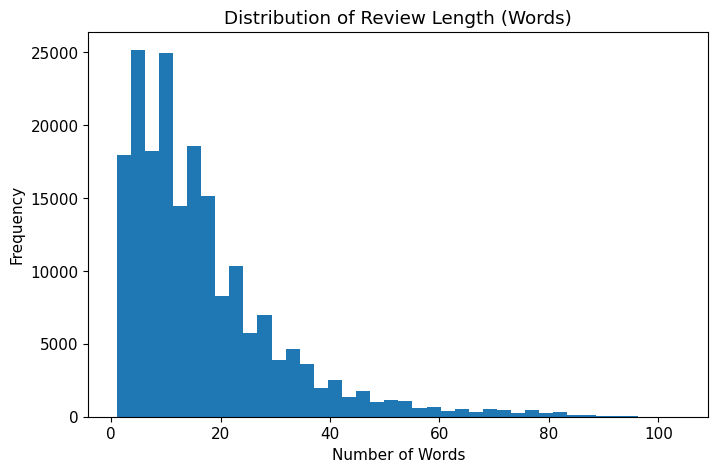

In [39]:
plt.figure(figsize=(8,5))

plt.hist(
    df["word_length"],
    bins=40
)

plt.title("Distribution of Review Length (Words)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

Review Timeline

In [40]:
df["time"] = pd.to_datetime(df["time"])

C:\Users\PC\AppData\Local\Temp\ipykernel_5088\3879457033.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


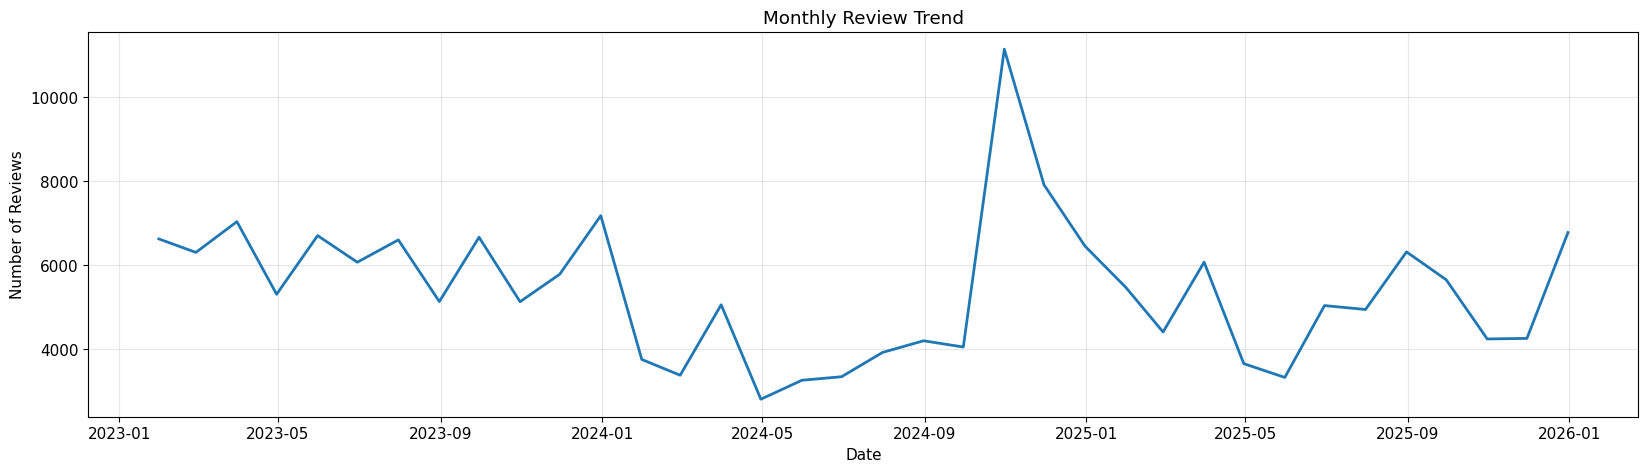

In [41]:
monthly_reviews = (
    df
    .set_index("time")
    .resample("M")
    .size()
)

plt.figure(figsize=(20,5))

plt.plot(
    monthly_reviews.index,
    monthly_reviews.values,
    linewidth=2
)

plt.title("Monthly Review Trend")
plt.xlabel("Date")
plt.ylabel("Number of Reviews")

plt.grid(alpha=0.3)

plt.show()

Year Distribution

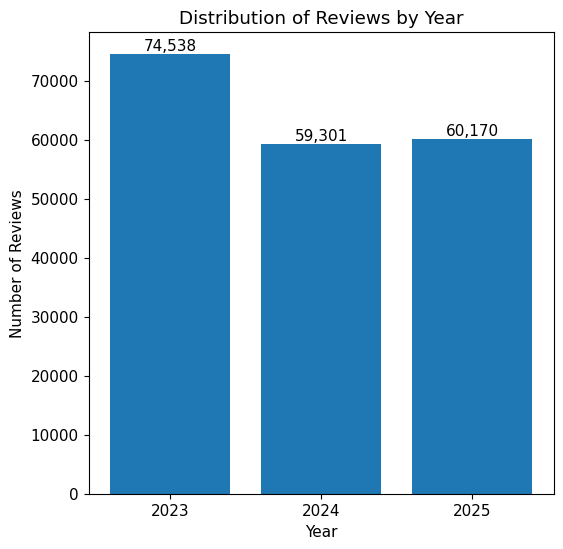

In [42]:
year_count = (
    df["year"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(6,6))

plt.bar(
    year_count.index.astype(str),
    year_count.values
)

plt.title("Distribution of Reviews by Year")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")

for i, v in enumerate(year_count.values):
    plt.text(i, v, f"{v:,}", ha="center", va="bottom")

plt.show()

short reviews 

In [43]:
df[
    df["word_length"] <= 3
][["content"]].head(20)

,content
3,bagus
25,sampah
37,mkain lemot
83,susah masuk login
89,aplikasi kacau
92,aplikasi buruk
111,merah terus !!!
112,jaringan merah mulu
152,potongan gak jelas!!
155,Aplikasi sering gangguan


longest reviews

In [44]:
df.nlargest(
    20,
    "word_length"
)[["word_length","content"]]

,word_length,content
161643,104,"M, vivy:b.mnm.. Bb bbbb bbvvc. l..... . . .. Mmmm lm. l.. l.. lkmmmmm. Mmmmmmmmmmmkmmmmm. Ml) mlm. llm. mlm. l. lm.. l. m. l. l. lmmm.ll.. Mll. Lmklkkkk.mmmmmmmmmmmmmkmkkkk... Mmmm Mmmm m M . l M M m Mmm M M... .. l. l.. l... . M.. Ml. . l. l.. l. . . ....... . . . ... ... M... . . ... . . . m. .. . . . . . . . . Mmmmmmmm . . ... . ... l.. , . ll. L. l. l....l..l.l.l.l . . . ... ll...l l l . ll... l.. l. l ..,.,. . M"
152105,102,"Tlong bgi yg mau dwload pikir² dulu ya, sy korban dr apk ini karna tdk bs login tanpa kartu debit smentara kartu debitny uda 6 bln sy tunggu tdk dtg². Pdahal di apk bilang 3-14 hr pling lama kartu debit di antar ke almt rmh, mana ada? Trs di apk ini ga bs tf pdahal minim 10rb, sy rencanany mau nonaktifkan akun Livin sy, tauny saldo sy ga bs di tf kemna pun pdahal uda sy sisakan 10rb utk depo di Livin ttp ga bisa. Akhirny sy hpus data & coba login malah ga bs login samsek. rugi saldo sy byk didlm"
46992,98,"saya mau isi saldo shoopay kok susah sekali ya, kalau mau isi saldo 2 juta aja ribet amat, hari ini trfer 1 juta pkek @wallet bisa, ntar kelang brpa jam gk bisa lagi. trz aku tfer 5rtus ribu bis, stlh itu gk bisa lagi, trz kirim lagi 3ratus bisa, trs sisanya mau trfer 2 ratus gk bisa lagi, jadi aku tf 100rbu bisa, mau tf lgi gk bisa lagi. adu pusing ya susah bner mau trfer ke shoopay aja ribet gitu. sebelumnya gk ada masalah mau tf brpa aja ke shoopay. sekarang ribet pusing gk tau salahnya dimna"
49056,98,"suruh buka rek di aplikasi brimo. awal pas di dkt satpam bisa di buka dan suruh isi dana 50rb abis itu blm sempat ketemu cs. kata satpam rek sdh bisa d gunakan. ok dong saya gak perlu ke cs karena klu tunggu cs katanya nanti jm3. hakirnya gue balik setelah berhasil gue tf 50rb ke rek yg baru gue buka. bsk nya gue mau buka aplikasi brimo tiba"" udh gk bisa di buka.sampe gue ke bank tdk di layanin dng baik. gue pake bca udh 20thn gak pernah ada kendala kaya bri dan dilayani dengan baik di bca"
66758,98,Pdhl enak kl pke brimo cmn kl ada tiap sms msuk dri brimo knp hrus kptong wlpn 500 perak brp kali msuk notifksi kptong bru kmrn liat smpe 5000 rbu kdg 2500.. nabung biar nmbah mlah gk dpt bunga kptong bwt biaya sms msuk dri brimo ntah promosi kl msal bwt notiksi ada keluar masuk uang gpp coba kl per sms 500 perak tiap ad notifiksi kptong aj udh byk cmn bwt promosi di brimo . Coba kl utk promosi brimo kptong ny 50 perak aj bukan mau nabung namany kl hbis cmn kptong biaya promo dri brimo
88360,98,Ni bri sialan banget ya. Saldo gw d ambilin mulu katanya untuk biaya kartu. Lah kan gw bikin kartu juga dah pake biaya. Knapa skarang harus d biayain lagi tu kartu. Emang dia bocah masih skolah yg harus d biayain. Lah trus itu duit yg lu potong dari hasil saldo gw d kmanain bego Dah mah plit pisan bri. Mau minjam aja d apk brimo nya ga d kasih padahal fitur pinjam d adakan dasar tolol. Klo gamau ngasih pinjaman. Untuk apa fitur pinjaan bri d adakan Anak sd juga tau yg namanya d adakan ya ad guna
100695,98,"Dulu pas prtma buat rekening, sy bs unduh aplikasi ini d samsung tab sy. skrg jd g bs samsek. Udh coba mngeluhkn k CS BRI, katanya HP sy g support dg aplikasi BRIMO krna aplikasi ini trs mngalami update, Mlah nyuruh gnti HP. Udah mh aplikasi BRIMO g bs d unduh, ehh..internet banking nya jg d tutup alias g bs d akses lg. Udh coba gnti HP lain msh sm sj. mgkin hp sy yg trlalu BUTUT! ribet makin kesini. mw transfer, cak cek & ricek, dll jd g bs. Jd BADMOOD sy d sini! Sia2 sj rasanya.KECEWA!!!"
63668,96,Sekedar saran untuk BRI.. kalau qris.a blm rampung jngn d pksakan untuk pake fitur itu d brimo.. Smpe sekarang dana sya 1 jt ngmbang g nympe d tujuan.. dan g balik.. scan code awal g brhsil.. trus scan lagi mlah d proses d 22.a stlah itu smpe skrng status sedang d proses pdhl slah satu transaksi udh ad yg brhasil g tau yg mana.. udh diskusi sama si pnrima dana.. cuma 1 x aja yg masuk .. yg 1 ngmbang.. trus status 22.a msih d proses kan g jelas jadi.a.. Klo anda..(developer) minta b

checking weird comments

In [45]:
df["content"].str.fullmatch(r"[A-Za-z\s.,!?]+", na=False).value_counts()

content
True     130710
False     63299
Name: count, dtype: int64

In [46]:
df[
    df["content"].str.len() < 30
][["content"]].sample(30, random_state=42)

,content
67649,Cepat
4859,knp gk bisa masuk ya
87949,Susah login
77792,Aplikasi nya anehhhh
136095,Email tidak dibalas
76151,Der
179985,sering eror
82292,Luar biasa
72890,Jaringann lelet
181603,updatnya lemot
